In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

df = pd.read_csv("housing_after_iqr.csv")
df_original = pd.read_csv("housing.csv")

In [3]:
df.head()

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,52.0,1467.0,496.0,7.2574,352100.0,17.84,0,0,0,1
1,52.0,1274.0,558.0,5.6431,341300.0,17.06,0,0,0,1
2,52.0,1627.0,565.0,3.8462,342200.0,17.06,0,0,0,1
3,52.0,919.0,413.0,4.0368,269700.0,17.06,0,0,0,1
4,52.0,2535.0,1094.0,3.6591,299200.0,16.55,0,0,0,1


In [4]:
df.describe()

,housing_median_age,total_rooms,population,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
count,17122.000000,17122.000000,17122.000000,17122.000000,17122.000000,17122.000000,17122.000000,17122.000000,17122.000000,17122.000000
mean,29.665168,2127.096250,1199.326889,3.553028,188757.913561,88.972010,0.437040,0.328642,0.000292,0.110443
std,12.207705,1055.340999,603.619296,1.405319,94635.184233,80.602766,0.496035,0.469733,0.017087,0.313450
min,1.000000,2.000000,3.000000,0.499900,14999.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,1375.000000,768.000000,2.494975,114800.000000,21.980000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,1975.000000,1113.000000,3.384000,171300.000000,58.570000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,2770.000000,1561.000000,4.453475,242200.000000,141.537500,1.000000,1.000000,0.000000,0.000000
max,52.000000,5127.000000,3199.000000,7.628600,500000.000000,326.600000,1.000000,1.000000,1.000000,1.000000


In [5]:
df_original.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# checking missing values
df.isnull().sum()

housing_median_age           0
total_rooms                  0
population                   0
median_income                0
median_house_value           0
distance_to_nearest_city     0
ocean_proximity_<1H OCEAN    0
ocean_proximity_INLAND       0
ocean_proximity_ISLAND       0
ocean_proximity_NEAR BAY     0
dtype: int64

In [5]:
#### X/y -split + VIF -test for multicollinearity
 # use everything else except, the target
X = df.drop("median_house_value", axis=1)

# our target variable is y
y = df['median_house_value']

In [6]:
# Finding columns with potential multicollinearity (VIF-test)
# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns  
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 
  

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, confusing the logistic regression
print(vif_data)

                     feature        VIF
0         housing_median_age   4.946927
1                total_rooms  16.470628
2                 population  13.606291
3              median_income   6.618157
4   distance_to_nearest_city   2.825093
5  ocean_proximity_<1H OCEAN   4.041095
6     ocean_proximity_INLAND   2.998567
7     ocean_proximity_ISLAND   1.002257
8   ocean_proximity_NEAR BAY   1.916196


<Axes: >

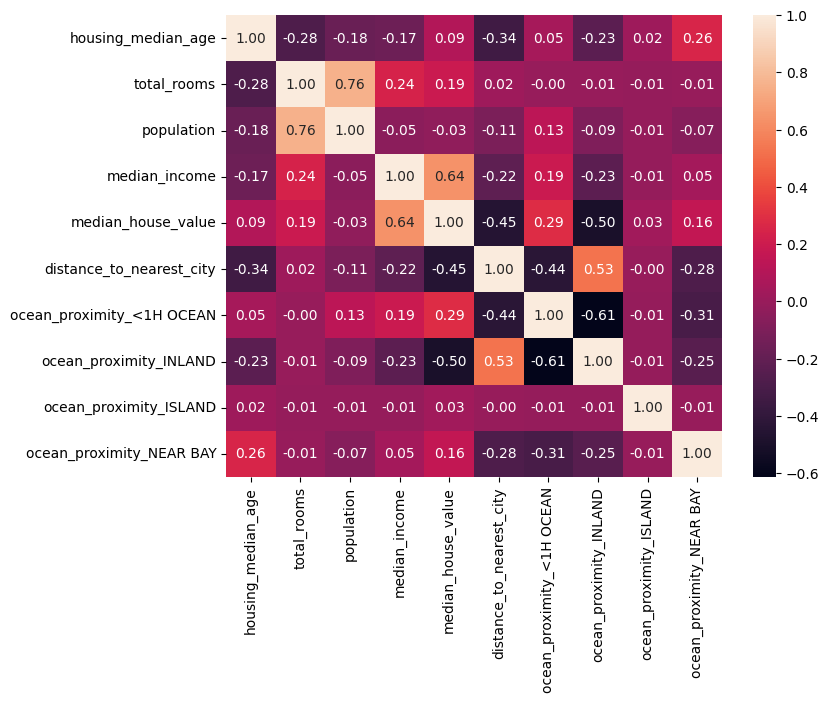

In [7]:
# correlation matrix 
plt.figure(figsize=(8, 6))

correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt='.2f')

In [8]:
df.columns

Index(['housing_median_age', 'total_rooms', 'population', 'median_income',
       'median_house_value', 'distance_to_nearest_city',
       'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY'],
      dtype='object')

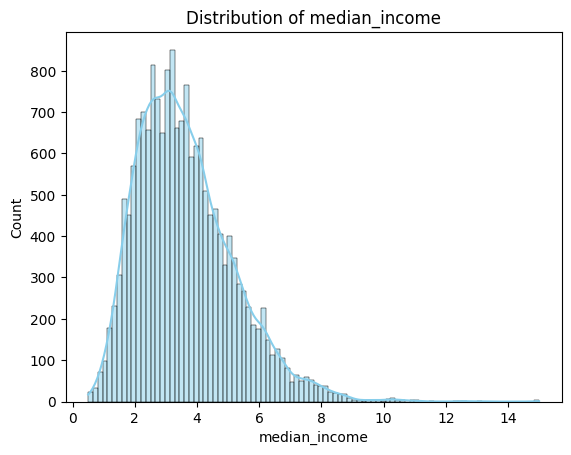

In [9]:
# check the distribution:
variable = 'median_income'

# Plot histogram
sns.histplot(df[variable], kde=True, color='skyblue')
plt.title(f'Distribution of {variable}')
plt.xlabel(variable)
plt.ylabel('Count')
plt.show()

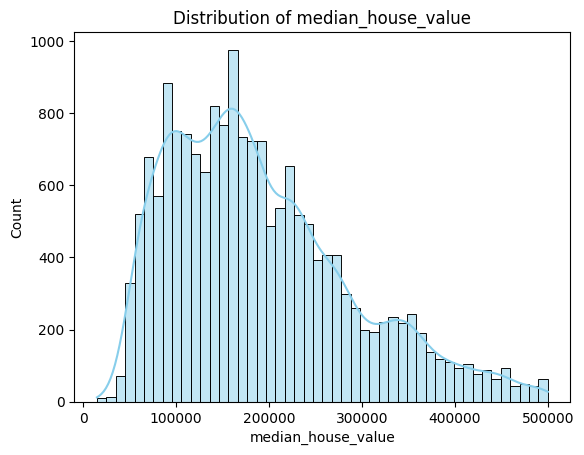

In [10]:
# check the distribution:
variable = 'median_house_value'

# Plot histogram
sns.histplot(df[variable], kde=True, color='skyblue')
plt.title(f'Distribution of {variable}')
plt.xlabel(variable)
plt.ylabel('Count')
plt.show()

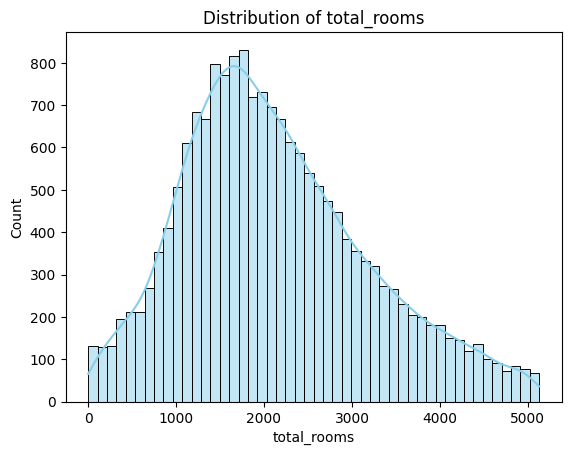

In [11]:
# check the distribution:
variable = 'total_rooms'

# Plot histogram
sns.histplot(df[variable], kde=True, color='skyblue')
plt.title(f'Distribution of {variable}')
plt.xlabel(variable)
plt.ylabel('Count')
plt.show()

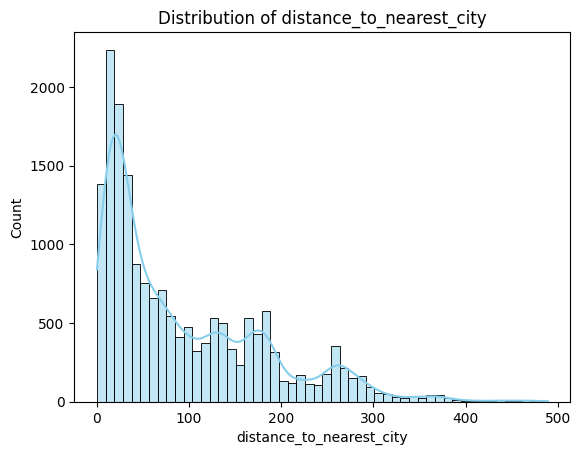

In [12]:
# check the distribution:
variable = 'distance_to_nearest_city'

# Plot histogram
sns.histplot(df[variable], kde=True, color='skyblue')
plt.title(f'Distribution of {variable}')
plt.xlabel(variable)
plt.ylabel('Count')
plt.show()

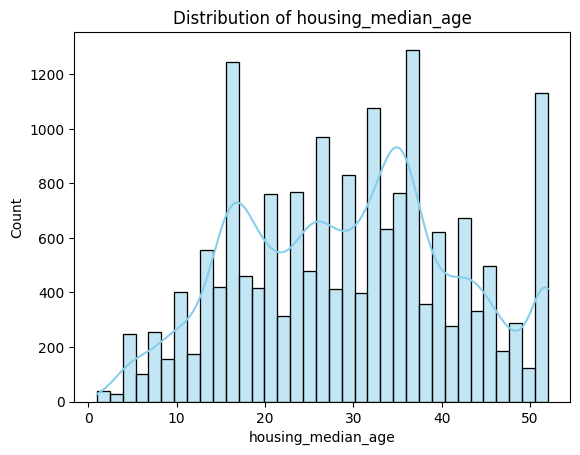

In [13]:
# check the distribution:
variable = 'housing_median_age'

# Plot histogram
sns.histplot(df[variable], kde=True, color='skyblue')
plt.title(f'Distribution of {variable}')
plt.xlabel(variable)
plt.ylabel('Count')
plt.show()